In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

plt.style.use('ggplot')

# Statistical Inference for a Single Population - Continuous Data

In the previous notebooks, we saw how to utilize different sampling and resampling methods, using the Central Limit Theorem (CLT) to describe the distribution of sample statistics. In this notebook, we will focus more on the inference side.

## Confidence Intervals

When making inferences about a population parameter, such as the mean, we can use analytical methods (based on distributional assumptions) or bootstrapping to generate confidence intervals.

**Example**

Let's say we are interested in the mean of a certain population, but due to financial constraints, we were able to collect only 30 data points.

In [2]:
np.random.seed(44)
population = np.random.randint(0,50,10000)
sample = np.random.choice(population,size = 30)
sample_mean = np.mean(sample)
sample_mean

np.float64(25.5)

The sample mean is 25.5. From the previous notebooks, we know that we cannot solely trust the sample statistic. We have to somehow report the variability of the point estimate.

We can utilize bootstrap resampling like we did in the previous notebook:

In [3]:
boots = stats.bootstrap((sample,),statistic = np.mean, random_state = 42)
boots.confidence_interval

ConfidenceInterval(low=np.float64(20.533333333333335), high=np.float64(30.033333333333335))

The good thing about bootstrapping is that it does not require any distribution-related assumptions. Independent of the sample distribution, the sample statistic distribution approaches normality thanks to the CLT.

However, analytical methods are often preferred for their simplicity and interpretability. Let's see how we can construct confidence intervals analytically.

## Confidence Intervals with Analytical Methods

### T-distribution for Continuous Random Variables

A perfect normal distribution is hard to obtain, especially with low sample sizes. In these cases, we use the *t-distribution* for confidence interval calculation.

You can think of the t-distribution as a normal distribution with fatter tails. It has an additional parameter $\nu$, which refers to the degrees of freedom (dof). As dof increases, the t-distribution converges to a normal distribution. For a single sample:

$\nu = n-1$ where $n$ refers to the sample size.

$\alpha = 0.05\quad$ for 95% confidence

$SE = \frac {s} {\sqrt{n}}$ where $s$ refers to the sample standard deviation.

$CI = \bar{x} \pm t_{\alpha/2,\nu} \times SE \quad$ for two-sided CI

As long as we have a somewhat normal distribution (no extreme outliers, all values are centered around the mean), we can use these formulas to get the confidence intervals.

So let's see the sample distribution of the data we are interested in:


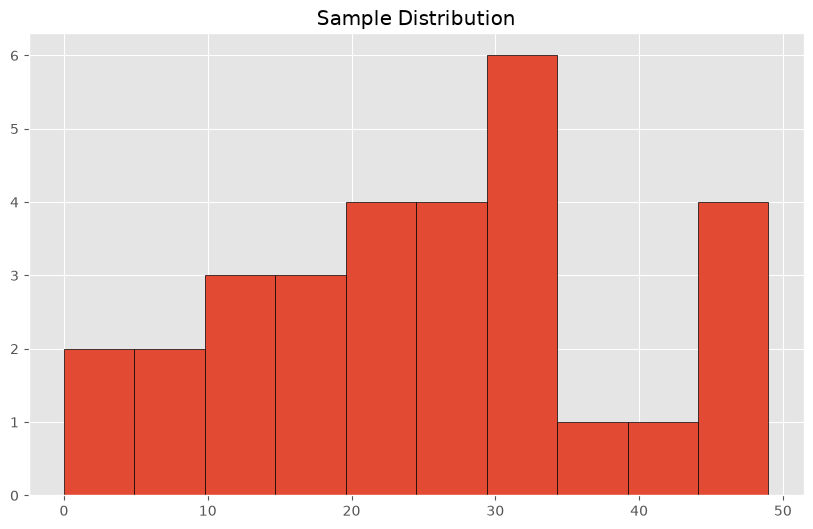

In [4]:
plt.figure(figsize=(10,6))
plt.hist(sample, bins=10, edgecolor='black')
plt.title("Sample Distribution")
plt.show()

The histogram looks roughly symmetric with no extreme outliers, so we can proceed with the t-distribution formula to calculate the confidence interval:

In [5]:
se = sample.std(ddof=1) / np.sqrt(len(sample))
dof = len(sample) - 1
t_val = stats.t.ppf(0.975,dof)
ci = (sample_mean - t_val * se, sample_mean + t_val * se)
ci

(np.float64(20.44936933087951), np.float64(30.55063066912049))

Note that the t-distribution based confidence interval is very close to the bootstrap confidence interval we calculated earlier, which shows that both approaches give similar results when the underlying assumptions are reasonably satisfied.

## Prediction Intervals

One of the common misapplications in statistics is using confidence intervals to make predictions. I have made this mistake myself. The correct approach is to use *prediction intervals*.

Prediction intervals indicate the range within which an unobserved observation is expected to fall. For a roughly normally distributed sample, the prediction interval is computed using the following formula:

$PI = \bar{x} \pm t_{\alpha/2,\nu} \times s\sqrt{1 + \frac{1}{n}}$




In [6]:
n = len(sample)
dof = n - 1
t_val = stats.t.ppf(0.975, dof)
s = sample.std(ddof=1)

pi_lower = sample_mean - t_val * s * np.sqrt(1 + 1/n)
pi_upper = sample_mean + t_val * s * np.sqrt(1 + 1/n)

print(f"Prediction Interval: ({pi_lower:.2f}, {pi_upper:.2f})")

Prediction Interval: (-2.62, 53.62)


Note that the original range that we sampled from is $(0,50)$. Considering the sample size, the prediction interval performed pretty well.

### Anomaly Detection Using Prediction Intervals

We can build a simple anomaly detection algorithm using prediction intervals:

```
If a data point does not lie within the prediction interval then flag it as an anomaly.
```

In [7]:
# Anomaly Detection
new_observation = 120

if new_observation < pi_lower or new_observation > pi_upper:
    print(f"Observation {new_observation} is OUTSIDE the PI ({pi_lower:.2f}, {pi_upper:.2f}) -> Anomaly")
else:
    print(f"Observation {new_observation} is WITHIN the PI ({pi_lower:.2f}, {pi_upper:.2f}) -> Normal")

Observation 120 is OUTSIDE the PI (-2.62, 53.62) -> Anomaly


### MAD (Median Absolute Deviation) Algorithm

The standard deviation is sensitive to outliers. If the data is contaminated, the SD-based prediction interval will be misleading. We can alternatively use the *MAD* algorithm instead.

$\text{MAD} = \text{median}(|X_i - \tilde{X}|)$

To use MAD as a scale estimator consistent with the standard deviation (for normal data), we apply a scaling factor:

$\hat{\sigma}_{MAD} = k \times \text{MAD}$

where $k = 1.4826$ for normally distributed data.

In [8]:
# MAD-based Prediction Interval
sample_median = np.median(sample)
mad = np.median(np.abs(sample - sample_median))
sigma_mad = 1.4826 * mad

pi_lower_mad = sample_median - t_val * sigma_mad * np.sqrt(1 + 1/n)
pi_upper_mad = sample_median + t_val * sigma_mad * np.sqrt(1 + 1/n)

print(f"MAD-based Prediction Interval: ({pi_lower_mad:.2f}, {pi_upper_mad:.2f})")

MAD-based Prediction Interval: (1.30, 53.70)
